<a href="https://colab.research.google.com/github/Graylab/FLAb/blob/main/examples/Rosetta_TechTeaTime_23_03_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<font color='#3399CC' size=6> FLAb tutorial: Benchmarking a protein language model for antibody developability prediction </font>**


A prominent application of machine learning in therapeutic antibody design is the development of models that can generate or screen antibody candidates with a high probability of success in manufacturing and clinical trials. Here we will investigate if a pretrained protein language model can be used to screen antibody candidates that have desirable levels of developability|.

**<font color='#3399CC' size = 5> Installation </font>**

We will investigate whether ESM2, a general protein masked language model, can be used to predict antibody developability. More information of the ESM2 model can be found here: https://huggingface.co/docs/transformers/en/model_doc/esm

In [1]:
import torch
import numpy as np
import torch.nn.functional as F
from transformers import EsmTokenizer, EsmForMaskedLM

from scipy.stats import spearmanr
import math

**<font color='#3399CC' size = 5> Zero-shot scoring with ESM2 8M </font>**

A common application of protein language models in fitness prediction is in a zero-shot setting, where a protein language models confidence is used to rank sequences, without any additional fine-tuning with dataset-specific sequences.

For zero-shot benchmarking, we use the antibody variable region sequence as inputs for each model to assess their predictive capabilities, based on the corresponding model’s perplexity scores (averaged over all residues in the heavy and light chains). We report the Spearman’s correlations to establish the connection between the model uncertainty values and the fitness metrics associated with the sequences in the dataset. If a protein language model implicitly captures the biophysical landscapes of a pretraining set of antibodies or general proteins during training, it should assign high confidence (low perplexity) to new, previously unseen antibodies that have high expression and low confidence (high perplexity) to new, low-expression antibodies.

In [2]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = EsmTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
model = EsmForMaskedLM.from_pretrained("facebook/esm2_t6_8M_UR50D").to(device)
model.eval()

def esm2_8M_score(seq: str) -> float:
    """
    Compute pseudo-perplexity using a single forward pass.
    Much faster and memory efficient.
    """
    inputs = tokenizer(seq, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    # Shift to remove CLS and SEP
    logits = logits[:, 1:-1, :]
    labels = inputs["input_ids"][:, 1:-1]

    log_probs = F.log_softmax(logits, dim=-1)

    # Gather log-probabilities of true tokens
    token_log_probs = log_probs.gather(
        dim=-1,
        index=labels.unsqueeze(-1)
    ).squeeze(-1)

    # Mean negative log likelihood
    nll = -token_log_probs.mean()

    return float(torch.exp(nll).cpu())


def score(method, df):
    """
    input: df with columns: heavy,
                            light,
                            fitness
    output: pearson correlation and pvalue
    """

    df = pd.read_csv(df, nrows=100)

    ### CALCULATE PERPLEXITIES ###
    # for dataframe with heavy,light (Fvs)
    df['heavy_perplexity'] = df['heavy'].apply(lambda seq: method(seq))
    df['light_perplexity'] = df['light'].apply(lambda seq: method(seq))

    # Calculate average perplexity
    df['average_perplexity'] = (df['heavy_perplexity'] + df.get('light_perplexity', 0)) / 2

    # Compute Spearman's correlation
    corr_ppl, p_value_ppl = spearmanr(df['average_perplexity'], df['fitness'])

    return corr_ppl, p_value_ppl, df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**<font color='#3399CC' size = 5> ESM2 8M correctly predicts favorable thermostability</font>**

`hie2023efficient_REGN10987_Tm.csv` contains a set of variants of a patient-derived antibody that binds early variants of SARS-CoV-2 Spike.

In [3]:
import pandas as pd

df_REGN10987 = pd.read_csv("https://github.com/Graylab/FLAb/blob/main/data/thermostability/hie2023efficient_REGN10987_Tm.csv?raw=true")
df_REGN10987.head()

,Antibody,heavy,light,HC_mut,LC_mut,Design,Tm,fitness
0,REGN10987,QVQLVESGGGVVQPGRSLRLSCAASGFTFSNYAMYWVRQAPGKGLE...,QSALTQPASVSGSPGQSITISCTGTSSDVGGYNYVSWYQQHPGKAP...,R7 VH,R7 VL,REGN10987,77.540000,77.540000
1,REGN10987,QVQLVESGGGVVQPGGSLRLSCAASGFTFSNYAMYWVRQAPGKGLE...,QSALTQPASVSGSPGQSITISCTGTSSDVGGYNYVSWYQQHPGKAP...,R16G,R7 VL,R16G,74.826667,74.826667
2,REGN10987,QVQLVESGGGVVQPGGSLRLSCAASGFTFSNYAMYWVRQAPGKGLE...,QSALTQPASVSGSPGQSITISCTGTSSDVGGYNYVSWYQQHPGKAP...,R16G-V108D,R7 VL,R16G-V108D,76.180000,76.180000
3,REGN10987,QVQLVESGGGVVQPGRSLRLSCAASGFTFSNYAMYWVRQAPGKGLE...,QSALTQPASVSGSPGQSITISCTGTSSDVGGYNYVSWYQQHPGKAP...,R7 VH,S82A-N91C-196S,S82A-N91C-I96S,80.173333,80.173333
4,REGN10987,QVQLVESGGGVVQPGGSLRLSCAASGFTFSNYAMYWVRQAPGKGLE...,QSALTQPASVSGSPGQSITISCTGTSSDVGGYNYVSWYQQHPGKAP...,R16G,S82A,R16G/S82A,78.420000,78.420000


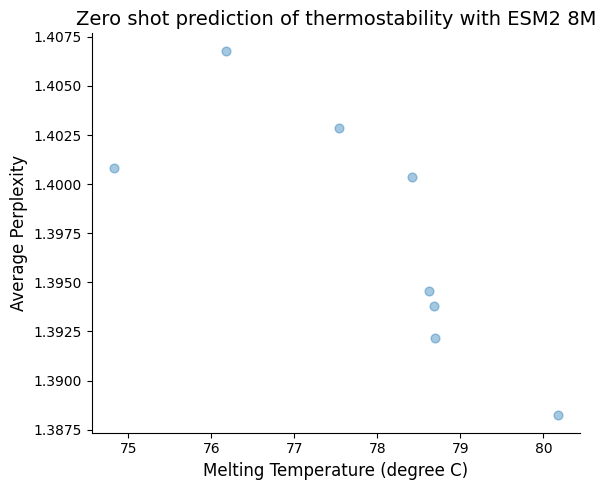

Spearman correlation: -0.9286
P-value: 8.6297e-04


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = "https://github.com/Graylab/FLAb/blob/main/data/thermostability/hie2023efficient_REGN10987_Tm.csv"
corr_ppl, p_value_ppl, new_df = score(esm2_8M_score, dataset+"?raw=true")

plt.figure(figsize=(6, 5))

# Scatter + smooth fit line with shaded confidence interval
sns.regplot(
    x='fitness',
    y='average_perplexity',
    data=new_df,
    scatter_kws={'alpha':0.4, 's':40},
    line_kws={'color':'#1f77b4', 'linewidth':3},
    #ci=95  # keep confidence interval shading,
    fit_reg=False
)

plt.xlabel("Melting Temperature (degree C)", fontsize=12)
plt.ylabel("Average Perplexity", fontsize=12)
plt.title("Zero shot prediction of thermostability with ESM2 8M", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

print(f"Spearman correlation: {corr_ppl:.4f}")
print(f"P-value: {p_value_ppl:.4e}")

ESM2 8M correctly assigns higher confidence (lower perplexity) to antibody variants with higher thermostability and lower confidence (higher perplexity) to antibodies with lower thermostability. Yay!

**<font color='#3399CC' size = 5> ESM2 8M incorrectly predicts binding affinity - but how do we interpret results?</font>**

`phillips2021binding_cr6261_h1_kd.csv` contains a set of variants of CR6261, a naturally affinity-matured influenza broadly neutralizing antibody (bnAb), which binds the conserved stem epitope of the influenza surface protein hemagglutinin (HA).

In [5]:
df_phillips2021binding_cr6261_h1 = pd.read_csv("https://github.com/Graylab/FLAb/blob/main/data/binding/phillips2021binding_cr6261_h1_kd.csv?raw=true")
df_phillips2021binding_cr6261_h1.head()

,genotype,heavy,light,h1_mean,h1_mean_neg_log_kd,fitness
0,10000100110,EVQLVQSGAEVKKPGSSVKVSCKASGGPFSSYAISWVRQAPGQGLE...,VLTQPPSXVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPKL...,8.980389,8.980389,8.980389
1,11000100110,EVQLVQSGAEVKKPGSSVKVSCKASGGPFRSYAISWVRQAPGQGLE...,VLTQPPSXVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPKL...,9.359923,9.359923,9.359923
2,11001100010,EVQLVQSGAEVKKPGSSVKVSCKASGGPFRSYAISWVRQAPGQGLE...,VLTQPPSXVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPKL...,9.348473,9.348473,9.348473
3,10000100100,EVQLVQSGAEVKKPGSSVKVSCKASGGPFSSYAISWVRQAPGQGLE...,VLTQPPSXVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPKL...,8.769334,8.769334,8.769334
4,11010100100,EVQLVQSGAEVKKPGSSVKVSCKASGGPFRSYAISWVRQAPGQGLE...,VLTQPPSXVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPKL...,9.396675,9.396675,9.396675


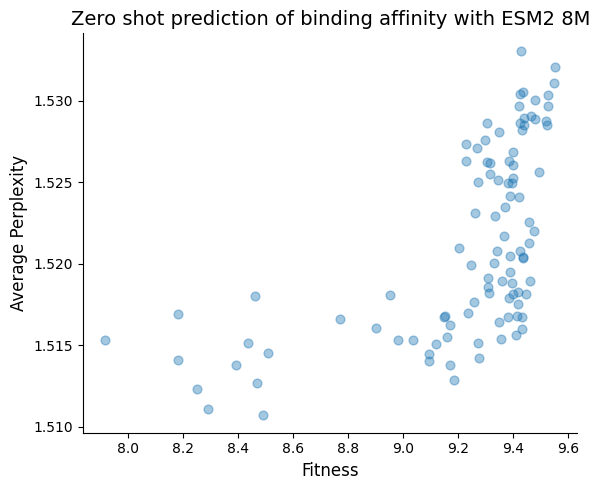

Spearman correlation: 0.6784
P-value: 8.8102e-15


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = "https://github.com/Graylab/FLAb/blob/main/data/binding/phillips2021binding_cr6261_h1_kd.csv"
corr_ppl, p_value_ppl, new_df = score(esm2_8M_score, dataset+"?raw=true")

plt.figure(figsize=(6, 5))

# Scatter + smooth fit line with shaded confidence interval
sns.regplot(
    x='fitness',
    y='average_perplexity',
    data=new_df,
    scatter_kws={'alpha':0.4, 's':40},
    line_kws={'color':'#1f77b4', 'linewidth':3},
    #ci=95  # keep confidence interval shading,
    fit_reg=False
)

plt.xlabel("Fitness", fontsize=12)
plt.ylabel("Average Perplexity", fontsize=12)
plt.title("Zero shot prediction of binding affinity with ESM2 8M", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

print(f"Spearman correlation: {corr_ppl:.4f}")
print(f"P-value: {p_value_ppl:.4e}")

ESM2 8M assigns lower confidence to the highest affinity binders, which might indicate a poor performance. But there is still a strong inverse correlation between both variables, so does that indicate ESM2 8M has some signal for predicting binding affinity in this dataset?

**<font color='#3399CC' size = 5> Understand the context behind your dataset</font>**

`marks2021humanization_immunogenicity.csv` contains therapeutic antibodies and their reported anti-drug antibody (ADA) responses in a given patient population. A higher ADA percentage indicates more patients exhbited an immunogenic reponse, while a lower ADA percentage indicates less patients exhibited an immunogenic reponse. Ideally, 0% of the patient population should have an ADA response.

In [7]:
df_marks2021humanization = pd.read_csv("https://github.com/Graylab/FLAb/blob/main/data/immunogenicity/marks2021humanization_immunogenicity.csv?raw=true")
df_marks2021humanization.head()

,heavy,light,%ADA response,fitness
0,QVQLKESGPGLVAPSQSLSITCTVSGFSVTNYGVHWVRQPPGKGLE...,SIVMTQTPKFLLVSAGDRVTITCKASQSVSNDVTWYQQKAGQSPKL...,100.0,100.0
1,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,68.1,68.1
2,EVQLQQSGAELVKPGASVKLSCTASGFNIKDTYVHWVKQRPEQGLE...,DILMTQSPSSMSVSLGDTVSITCHASQGISSNIGWLQQKPGKSFMG...,35.5,35.5
3,QVQLVQSGAEVKKPGASVKVSCKVSGYTLSDLSIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,0.4,0.4
4,QVQLVESGGGVVQPGRSLRLSCAASGFSFSNYGMHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQHKPGKAPKL...,0.0,0.0


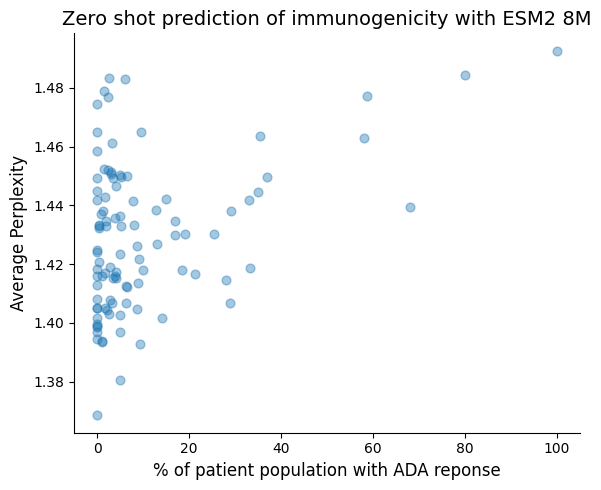

Spearman correlation: 0.2394
P-value: 1.6433e-02


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = "https://github.com/Graylab/FLAb/blob/main/data/immunogenicity/marks2021humanization_immunogenicity.csv"
corr_ppl, p_value_ppl, new_df = score(esm2_8M_score, dataset+"?raw=true")

plt.figure(figsize=(6, 5))

# Scatter + smooth fit line with shaded confidence interval
sns.regplot(
    x='fitness',
    y='average_perplexity',
    data=new_df,
    scatter_kws={'alpha':0.4, 's':40},
    line_kws={'color':'#1f77b4', 'linewidth':3},
    #ci=95  # keep confidence interval shading,
    fit_reg=False
)

plt.xlabel("% of patient population with ADA reponse", fontsize=12)
plt.ylabel("Average Perplexity", fontsize=12)
plt.title("Zero shot prediction of immunogenicity with ESM2 8M", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

print(f"Spearman correlation: {corr_ppl:.4f}")
print(f"P-value: {p_value_ppl:.4e}")

**<font color='#3399CC' size = 5> What's the right performance metric for your use case?</font>**

**Spearman correlation** - Spearman correlation measures how well the rank ordering of predictions matches the true ranking (e.g., whether higher predicted scores correspond to higher true fitness). Values range from -1 to 1, where 1.0 is perfect agreement, 0.0 indicates no monotonic relationship, and -1.0 is perfect inverse ranking; higher (closer to 1) is better.

**NDCG@10** - evaluates how well the model ranks the top 10 candidates, giving more weight to correctly ordering the very best candidates. Values range from 0 to 1, where 1.0 means a perfect top-10 ranking, and 0.0 indicates the ranking is maximally poor; higher is better.

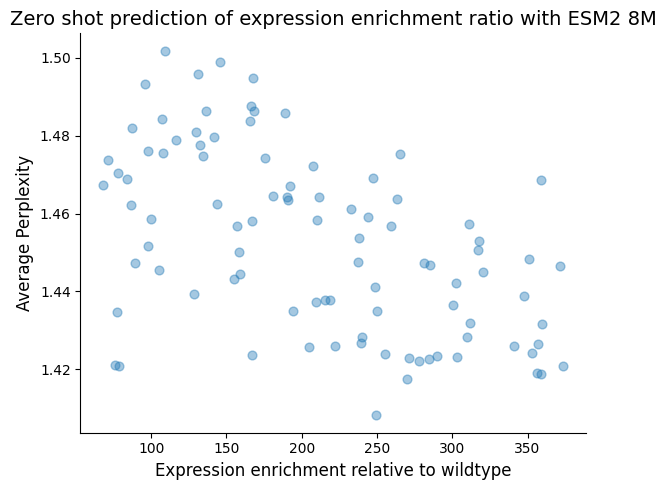

Spearman correlation: -0.5190
P-value: 8.3386e-08
NDCG@10: 0.7255


In [10]:
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def score(method, df, k=None):
    df = pd.read_csv(df, nrows=100)

    df['heavy_perplexity'] = df['heavy'].apply(lambda seq: method(seq))
    df['light_perplexity'] = df['light'].apply(lambda seq: method(seq))

    df['average_perplexity'] = (
        df['heavy_perplexity'] + df['light_perplexity']
    ) / 2

    df = df.dropna(subset=['average_perplexity', 'fitness'])

    ### --- SPEARMAN ---
    spearman_corr, spearman_pval = spearmanr(
        df['average_perplexity'], df['fitness']
    )

    ### --- NDCG ---
    y_true = df['fitness'].values.reshape(1, -1)
    y_score = (-df['average_perplexity'].values).reshape(1, -1)

    if k is not None:
        ndcg = ndcg_score(y_true, y_score, k=k)
    else:
        ndcg = ndcg_score(y_true, y_score)

    return spearman_corr, spearman_pval, ndcg, df


dataset = "https://github.com/Graylab/FLAb/blob/main/data/expression/garbinski2023_exp.csv"

corr_ppl, p_value_ppl, ndcg_val, new_df = score(
    esm2_8M_score,
    dataset + "?raw=true",
    k=10
)

plt.figure(figsize=(6, 5))

sns.regplot(
    x='fitness',
    y='average_perplexity',
    data=new_df,
    scatter_kws={'alpha': 0.4, 's': 40},
    line_kws={'linewidth': 3},
    fit_reg=False
)

plt.xlabel("Expression enrichment relative to wildtype", fontsize=12)
plt.ylabel("Average Perplexity", fontsize=12)
plt.title("Zero shot prediction of expression enrichment ratio with ESM2 8M", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

print(f"Spearman correlation: {corr_ppl:.4f}")
print(f"P-value: {p_value_ppl:.4e}")
print(f"NDCG@10: {ndcg_val:.4f}")